# PHAS0020 Session 1: Detectors, dark current with histograms and normal distributions
_Author: g.savini@ucl.ac.uk     (edited 15/01/2026)_

<div class="alert alert-success"> 

**Intended learning outcomes**

This first session's focus is to mostly revise many of the things you have already done last year in PHAS0007 with a focus on real detector data and its analysis.

**So we'll take a few sets of data and look at the statistics involved. Specifically:**

<ul>
<li> Use Python to generate a standard plot with all elements as well as a histogram plot of the same data set.</li>
<li> Use the statistical results of the analysis to characterise the performance of the detector of provenance... </li>
<li> ... and identify outlying detector pixels. </li>
<li> Use the histogram plot and fit a gaussian distribution function to showcase the primary nature of the data.</li>
<li> Dig deeper in the analysis by: </li>
<li> Performing a jack-knife tests and use the same tools as before on the dataset to identify potential instrumental features of the data set. </li>
<li> With some background on the data provenance, provide any evidence-based suggestion at such effects. </li>
<li> Perform the same statistical analysis on different integration times to separate bias from dark current (the latter expressed as counts/pixel/s). </li>
<li> With knowledge on the bias counts, use the same statistical analysis to calculate the DarkCurrent as a function of Temperature. </li>
</div>

The first task has a number of "fill-in-the-blanks" style tasks... as we progress through this half of term, these will give way to more "blank" tasks where a description of what is required is provided based on concepts and routines you have already seen last year or here. The notebook will guide you through what you need to do, and at various points you will find empty code cells that you need to complete in order to proceed.


## TASK 1 Getting started: Importing the data

The first thing we need to do is import the modules we will need. In this case we'll be using numpy and matplotlib.pyplot. We'll also tell the notebook to produce all the plots inside the notebook for convenience.

In [4]:
import numpy as np
import matplotlib.pyplot as plt #start with importing libraries that we will use

# In general, I prefer you have all plot outputs as images within the notebook. 
#This is done by using
%matplotlib inline


We're going to import some data from a text file into an array using numpy's loadtxt function. Make sure you've downloaded the associated data file  from Moodle, and that it is saved in the *same directory/folder as this notebook*. 

The file contains a double column of numbers representing the results of a series of measurements of the same quantity. Use `np.loadtxt` to import the contents of the file into an array called "data". 
Do this in the cell below:

In [7]:
### STUDENT GENERATED CELL ###
#insert correct path below

#we can check the path by running 'pwd'
path = '/Users/klarakurucova/Desktop/UCL /Practical astrophysics and computing /week 1/PythonTask_1'

#loading the first csv file 
data = np.loadtxt('Dark_1000ms.csv',delimiter=',',skiprows=48)

<div class="alert alert-warning"> 

**The Data set**

It is important to understand the provenance of your data (as you have seen last year in 0003).
In this case, we are looking at a 3648 pixel detector housed in a commercial (Thorlabs) spectrometer used for generic applications (not necessarily an astronomy-specific tool, but similar for all intents and purposes.

The data taken in this specific file was a **1 second dark** integration.

The statement above is key. It tells you the integration time (actually 1000 ms) and the conditions in which this was taken.

It is important to also realise that while we should always strive to acquire as much information as possible, life is a trade-off on how much we want to understand ourselves and how much we decide to commit to the "trust"-pot. [PHILOSOPHICAL off ramp]

As you recall from last year, the output $D$ of a detector (and therefore for each pixel) can be summarised as:

$$ D = B + DC \cdot t + S(t) $$

the sum of a Readout or Bias $B$, the thermal noise or dark current $DC$ which grows linearly with time $t$ and whichever signal $S(t)$ is arriving on the detector.

The fact that earlier we pointed to the dataset being "Dark", implies that we expect $S(t)=0$. This way we expect our data to have an average value which will be the result of sum of the Bias and one second worth of dark current.

To check that the file has imported correctly, we can use **np.info()** to investigate the imported data in our "data" array.
Some of the key information involved is the shape of the array and the overall number of points.

In [11]:
print(np.info(data))

class:  ndarray
shape:  (3648, 2)
strides:  (16, 8)
itemsize:  8
aligned:  True
contiguous:  True
fortran:  False
data pointer: 0x150008000
byteorder:  little
byteswap:  False
type: float64
None


We see that the data has been imported successfully as it agrees with the previously stated 3648 pixel detector. The shape also tells us there are two columns to this data set.

If you've successfully imported the data, you should be able to see that the data set has 2 columns. 
Now separate the two columns as you have learned last year. 
Name each column of the array with a new variable. 
The first column represents the wavelength of a 3648 pixel detector used in a spectrometer.
**Note:** This value is not a *truth* but an isomorphism between detector pixels and the wavelength of the light input in the spectrometer and dispersed by the optical element (diffraction grating) inside it onto the pixels.

In truth the association is more complicated than this as we will learn in Session 3, but for now we can consider it as such, and the fact that the data is dark lightens our knowledge burden.

In the next cell, isolate the two columns of the data set and associate separate variables for wavelength and detector signal.

In [15]:
### STUDENT GENERATED CELL ###

#isolating the csv data loaded into array 'data' into two columns: wavelength and detector signal  
wavelength = data[:,0] #as first column has index 0
detector_signal = data [:,1] #and second column has index 1


## Visualize the data set
It's always good practice to visualize your data set, before you do anything to it (if the size allows it!).
To review what you have done last year, please create a figure where you:
<ul>
    <li> Create the plot such that the width is that of the notebook but the height is such that it doesn't exceed that of the screen </li>
    <li> The plot should have a title, and an axis title for each axis (including units) - you can use (A.U. for Arbitrary Units for the y axis).</li>
    <li> Add a grid in the plot window, this is not always useful, but sometimes help guide the eye in comparing features and scales. </li>
    <li> Before finalizing this, try to output the plot with dots instead of a line... then decide which gives you a *clearer* view of the data. While it is good practice, when you have a few points, to represent these as such rather than joining them with a line (or worse with a smoothed line), there can be cases where this is ac</li>
</ul>

In the cell below, plot the 1D single data set as loaded

Text(0, 0.5, 'Detector Signal [A.U.]')

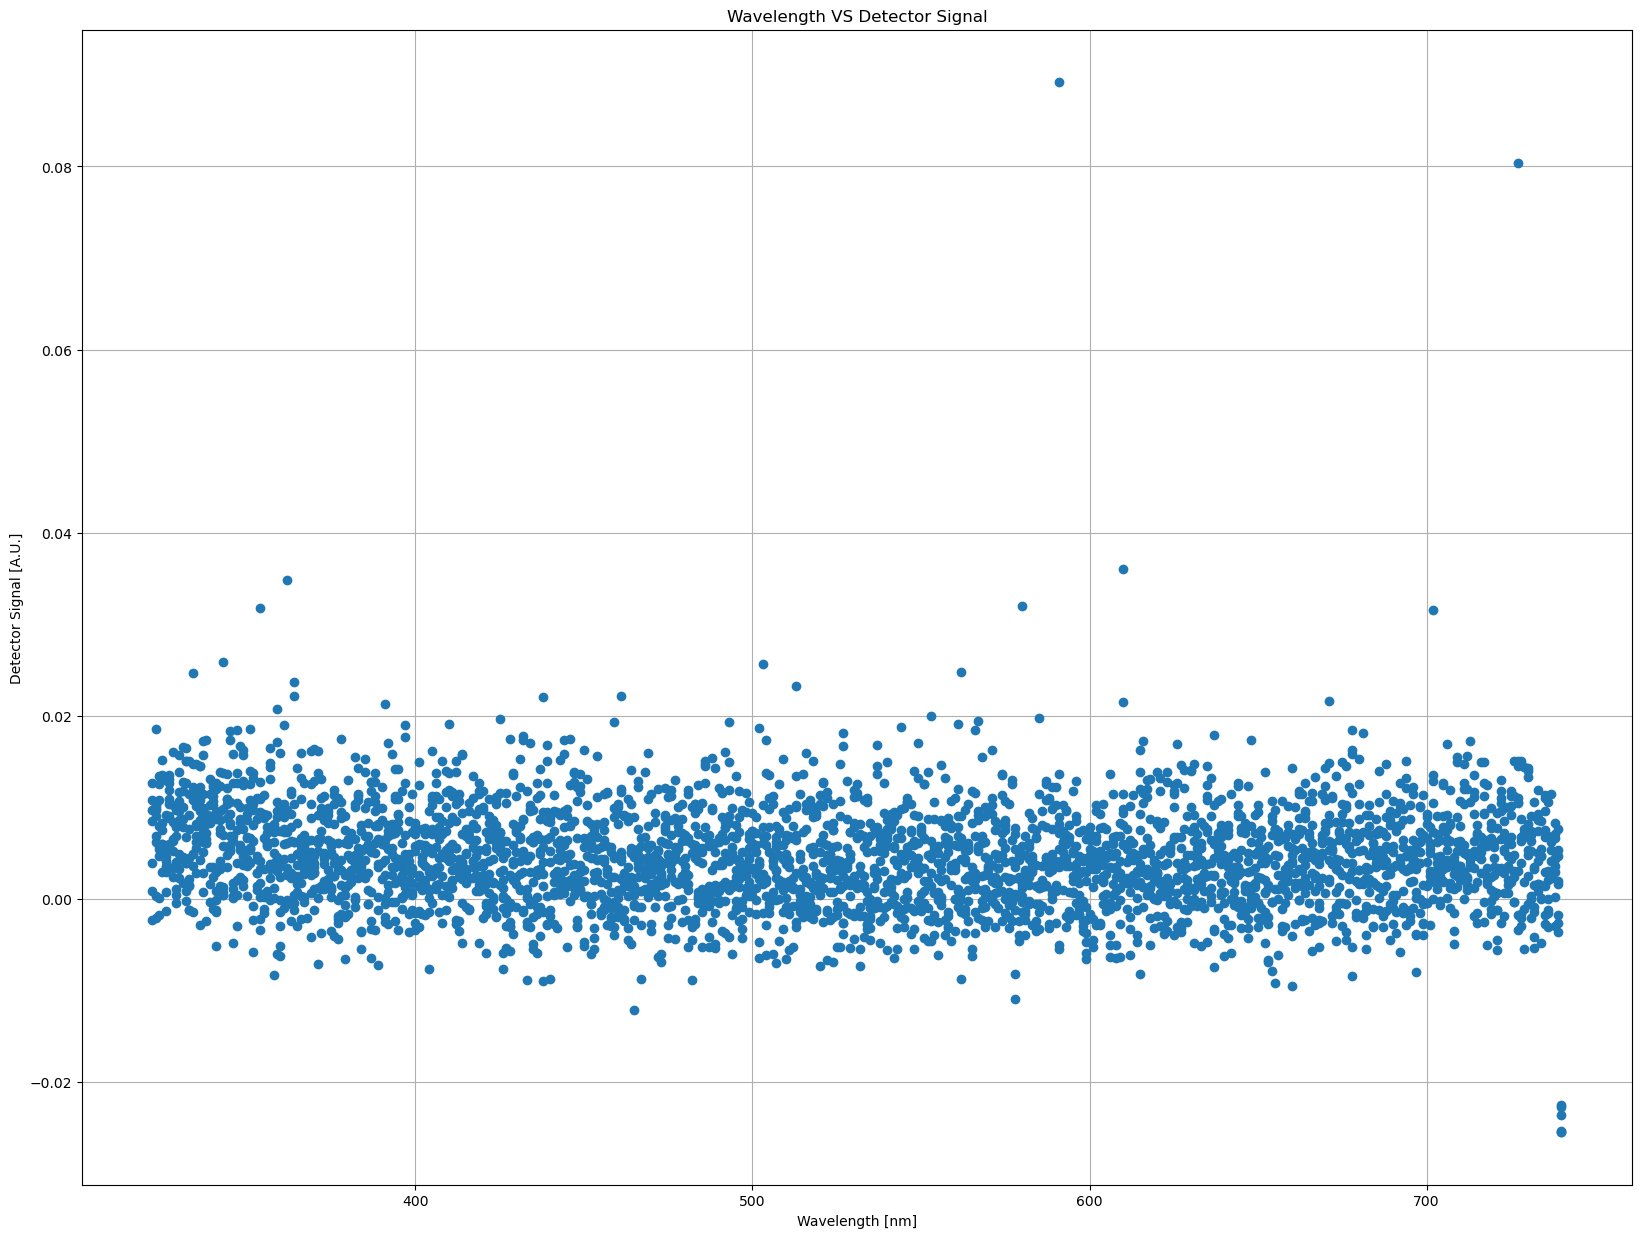

In [18]:
### STUDENT GENERATED CELL ###

#plotting the data set
#wavelength on x-axis, detector_signal on y-axis
plt.figure(figsize=(20,15)) #sets appropriate size of figure 
plt.plot(wavelength, detector_signal, "o") 
plt.grid()

#adding plot details
plt.title('Wavelength VS Detector Signal')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Detector Signal [A.U.]')



Upon initial insecption of the data, we see that most of the data points reside in the range of -0.01 to 0.02 of the detector signal (as a rough estimate). We also witness quite a few outliers that might have the potential to impact future data analysis and statistics.

Now, before we look at histograms, let's use the definitions we are familiar with to compare the standard deviation obtained with numpy _np.std()_ with one that you calculate knowing the definition of standard deviation.

Try comparing it also with the Estimator of the standard deviation and see which of these definitions coincides with the one used by numpy.

In the cell below we will compute the standard deviation using three cases:
- A) Using the NumPy.std() built in function
- B) Using the following formula for standard deviation:
$$
\sigma = \sqrt\frac{(\sum(x_i - \bar{x})^2)}{n}
$$
- C) Using the following formula for standard deviation:
$$
\sigma = \sqrt\frac{(\sum(x_i - \bar{x})^2)}{n-1}
$$
Where:
- $x_i$ = detector signal
- $\bar{x}$ = mean value of detector signal
- $n$ = number of data points in detector signal data sample

The point of this procedure is to figure out whether python's np.std() calculates Case B or Case C

In [23]:
### STUDENT GENERATED CELL ###

#python computed std using the NumPy function
np_python_std = np.std(detector_signal)
print(f"The NumPy standard deviation of the detector signal is: {np_python_std:.7f}")

#std with n
standard_dev = np.sqrt(np.sum ((detector_signal - np.mean(detector_signal))**2)/ len(detector_signal))
print(f"The computed standard deviation for case B is: {standard_dev:.7f}")

#std with n-1
standard_dev_minus1 = np.sqrt(np.sum ((detector_signal - np.mean(detector_signal))**2)/ (len(detector_signal) - 1))
print(f"The computed standard deviation for case B is: {standard_dev_minus1:.7f}")




The NumPy standard deviation of the detector signal is: 0.0057721
The computed standard deviation for case B is: 0.0057721
The computed standard deviation for case B is: 0.0057729


Hence we conclude that np.std() uses the number of data points in its denomaintor and coincides with the calculated Case B.

### Creating a histogram

In theory, because our data is assumed to be a set of repeated measurements of the same quantity (dark current of a single pixel), the distribution of the values should follow a Gaussian (normal) distribution, i.e. when we plot a histogram of the data, its shape should fit

$$ f(x) = \frac{1}{\sigma \sqrt{2\pi}} \exp \left[-\frac{(x-\bar{x})^2}{2\sigma^2}\right], $$
where $\bar{x}$ is the mean value of the data, and $\sigma$ the standard deviation.

We know that this is strictly incorrect as each data point belongs to a different pixel, but for now...
To see if this is true, we'll first plot the data as a histogram. We'll use the `plt.hist` function to automatically sort the data into bins and plot the resulting histogram. Do this in the cell below.

Text(0, 0.5, 'Frequency')

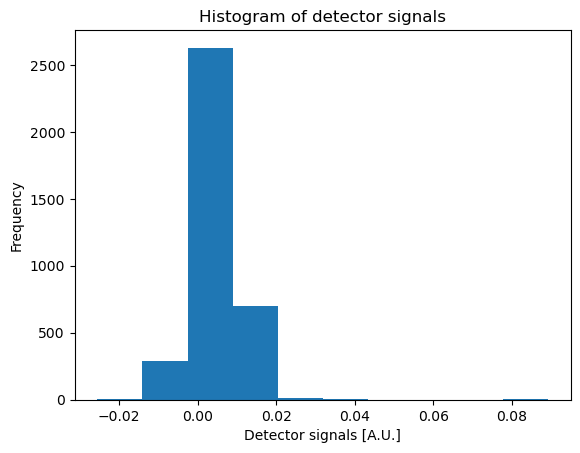

In [27]:
### STUDENT GENERATED CELL ###

#plotting a basic histogram of detector_signal data
plt.hist (detector_signal)

#adding plot elements
plt.title('Histogram of detector signals')
plt.xlabel('Detector signals [A.U.]')
plt.ylabel('Frequency')



It's often useful to be able to see the outline of the histogram bins, which is turned off by default in Matplotlib 2. You can do this by adding the keyword " edgecolor='black' " in the hist call.
Try also testing the functionality of " density = True " which will create frequency values which depend on the width of the bin considered. Lavel the Y axis appropriately.

Text(0, 0.5, 'Probability density')

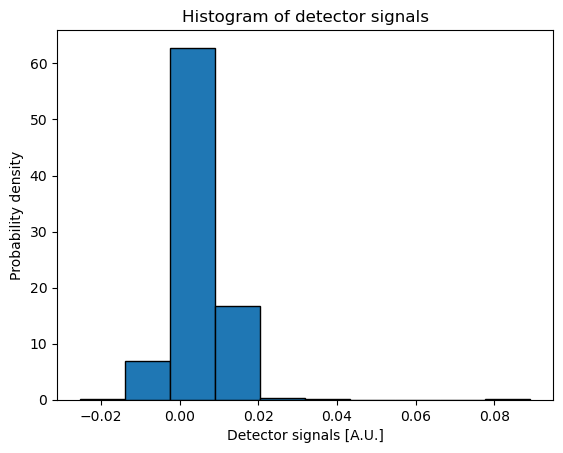

In [30]:
### STUDENT GENERATED CELL ###

#let's set some additional attributes to the histogram
#setting density = True transforms the y-axis into probability density 
plt.hist (detector_signal, edgecolor='black', density = True)

#adding plot elements
plt.title('Histogram of detector signals')
plt.xlabel('Detector signals [A.U.]')
plt.ylabel('Probability density')


Use the command "hist, bin_edges = np.histogram(ydata,bins=nbins,density=True) " to assign to the variables "hist" and "bin_edges" the y and x values of the histogram itself.
Now in the following cell also create an x vector using the "bin_edges" variable so you can overplot single points coinciding with the central position of each histogram bin.

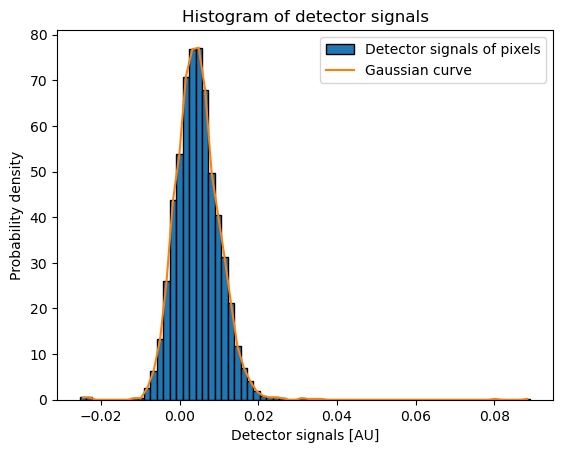

In [33]:
### STUDENT GENERATED CELL ###

#store values of the histogram: hist = yvals, bin_edge = xval
hist, bin_edges = np.histogram(detector_signal, bins= 70 ,density=True)

#finding the bin centre of our bin edges
bin_central = 0.5 * ((bin_edges[:-1] + bin_edges[1:]))

#plotting a gaussian curve over the histogram
plt.hist (detector_signal, edgecolor='black', bins = 70, density = True, label = "Detector signals of pixels")
plt.plot (bin_central, hist, label = "Gaussian curve")

##adding plot elements
plt.title('Histogram of detector signals')
plt.xlabel('Detector signals [AU]')
plt.ylabel('Probability density')
plt.legend ()


The values of the (density=True) histogram can be multiplied by the bin_size to obtain an integral-normalized histogram.
Verify below, that the histogram is thus normalized to an integral of 1.

In [36]:
#compute the bin size to check if they are normalised to one
bin_size = hist*((-bin_edges[:-1] + bin_edges[1:]))

#notify the user if their histogram is normalized
if sum(bin_size) == 1:
    print ("The plot is an integral normalized histogram")
else:
    print ("Error! Please check if you set density = True in your histogram")


The plot is an integral normalized histogram


By default, the matplotlib hist command puts the data into 10 bins. You can see all the possible options in the documentation http://matplotlib.org/api/pyplot_api.html?highlight=hist#matplotlib.pyplot.hist, but in general the only things you're likely to need to change are:
* The number of bins.
* Whether or not the histogram is normalised (normed) - in this case the integral of the histogram will be equal to 1.

For example, this will sort the data into 15 bins, and normalize the histogram:

### How well does this fit to a Gaussian?

Our data looks as though it may be roughly Gaussian. How can we check this?

We'll use another python module: scipy.stats, to find out. (Documentation link: https://docs.scipy.org/doc/scipy/reference/stats.html )

In [40]:
import scipy.stats as stats

Specifically, we'll use norm.fit to fit the data that we used in the histogram to a Gaussian, and give us the two parameters $\bar{x}$ and $\sigma$.
In the cell below use a command such as " x0, sigma = stats.norm.fit(ydata) " where "ydata" will be replaced by whichever variable you have used to identify the values of the pixels.
And print the values with an explanation of what those values are.

In [43]:
### STUDENT GENERATED CELL ###

#using norm.fit to evaluate average and standard deviation of our Gaussian fit
x0, sigma = stats.norm.fit(detector_signal)

print (f"The sample's average is: {x0:.5f}")
print (f"The sample's standard deviation is {sigma:.5f}")



The sample's average is: 0.00451
The sample's standard deviation is 0.00577


We can see from the first plot of the data, that while the average seems reasonable, the identified standard deviation encompasses most of the data (and we know that is an over estimation. This can be confirmed visually by producing a gaussian with these constants and overplotting it to the histogram.

Now we want to plot the fitted Gaussian on top of the histogram to see how good the fit is. In the cell below, write a suitably-named function that will return a Gaussian 
$$y = \frac{1}{\sigma \sqrt{2\pi}} \exp \left[-\frac{(x-\bar{x})^2}{2\sigma^2}\right], $$
for an input $x, \bar{x}$, and $\sigma$.


In [46]:
### STUDENT GENERATED CELL ### 

def gaussian (x, x_mean, s):
    '''A basic function that calculates the Gaussian of a data set using the formula stated above
    Inputs: x = bin centre
            x_mean = mean value of distribution
            s = standard deviation of distribution
    Returns: y = Gaussian curve'''
    
    y = (1/(s*np.sqrt(2*np.pi)))*np.exp(-((x - x_mean)**2)/(2*s**2))
    return y


Now complete the cell below to:
1. use the x vector created earlier representing the bin centres
2. use your function to create a corresponding array of y-values with a Gaussian form.

In [49]:
### STUDENT GENERATED CELL ### 

#call the function Gaussian to generate a curve for our data
gauss = gaussian (bin_central, x0, sigma)

In the following cell overplot the (normalised) histogram with a gaussian with same mean and standard deviation as your sample (this can also be done by using the command stats.norm.pdf (look it up).

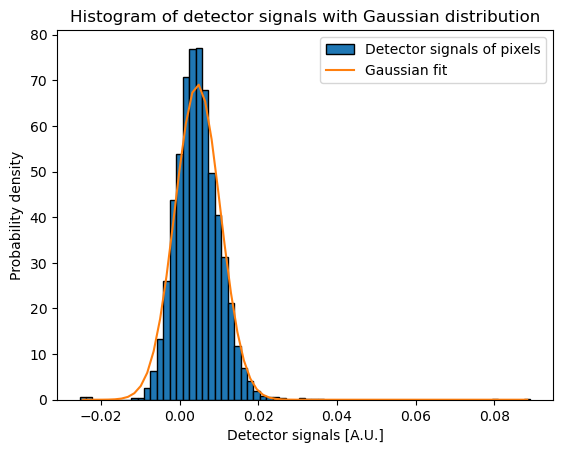

In [52]:
### STUDENT GENERATED CELL ### 

#plotting the gaussian over the histogram
plt.hist (detector_signal, edgecolor='black', bins = 70, density = True, label = "Detector signals of pixels")
plt.plot (bin_central, gauss, label = "Gaussian fit")

#adding plot elements
plt.title('Histogram of detector signals with Gaussian distribution')
plt.xlabel('Detector signals [A.U.]')
plt.ylabel('Probability density')
plt.legend ()



While in the previous distrbution the curve took y-values on the historgram making it fit directly on to the bins. The the latter plot, we use our gaussian function to generate the curve instead. We see that is mirrors the shape of the histogram very well, hence encompasing the entire spread of the detector signals. We see a discrepancy at the peak values, but this is because we are dealing with imperfect data that might not be fully Gaussian. 

Comment below in a Markdown cell, if this distribution looks good and corresponds to the spread of the data points in your opinion, and explain why or why not.

(Note if the plot becomes "messy" depending on the opacity of the histogram, you can use the extra option "alpha=0.25" in the hist function - this makes the histogram bars transparent, which makes the graph look a lot more visually clear when you're plotting lines on top of a histogram.)

In the above graph make sure you are using all elements appropriately (title, axes titles, legend)

# TASK 2
In the cell below use stats.moment to store the normalised moments of your data set. This makes the standard deviation readily available.
Print out these values.

**A note on moments:**
- We can find moment using stats.moment (array, order = n)
- Different orders give us different quantities, these include:
- n = 1: Mean
- n = 2: Variance
- n = 3: Skewness

We will be using n = 2 in the following code

In [58]:
#STUDENT GENERATED CELL 

#finding variance using stats.moment
moments_norm = stats.moment(detector_signal, order = 2) #second order gives variance
print (f"The variance of detector signal data is {moments_norm:.7f}")

#find standard dev
std = np.sqrt(moments_norm)
print (f"The standard deviation using stats.moments for the detector signal data is: {std:.3f}")


The variance of detector signal data is 0.0000333
The standard deviation using stats.moments for the detector signal data is: 0.006


In [60]:
### STUDENT GENERATED CELL - add more code and text cells as necessary! ###
#
# 1. Use the moments to find what are supposedly the "outlier" pixels from this distribution.
# While outlier threshold can often be set arbitrarily, try and give a statistical justification in units of sigma, to the value you choose.

# 2. Having identified these pixels, use "np.where()" to store the address indices of these points in a variable (or the address of 
#    all the other pixels). Plot the original data set as a line and overplot the outliers as single points for visual confirmation.

# 3. Now Re-calculate the statistics of the dataset without the outliers. Plot the histogram with overlapping gaussians (the previous one and 
#    one without outliers and comment on which of the two normal distributions appears more representative.



We are now going to find the outliers by setting an outlier threshold. We set the threshold to be $±3\sigma$ as statistically 99.7% of data should reside in this range. 

In [63]:
#using moments to find outlier pixels in the distribution 

#outlier threshold = 3 standard deviations
outlier_threshold = 3*std

#identify pixels that have standard deviation greater than outlier threshold using np.where 
outliers = np.where (np.abs(detector_signal) > outlier_threshold)



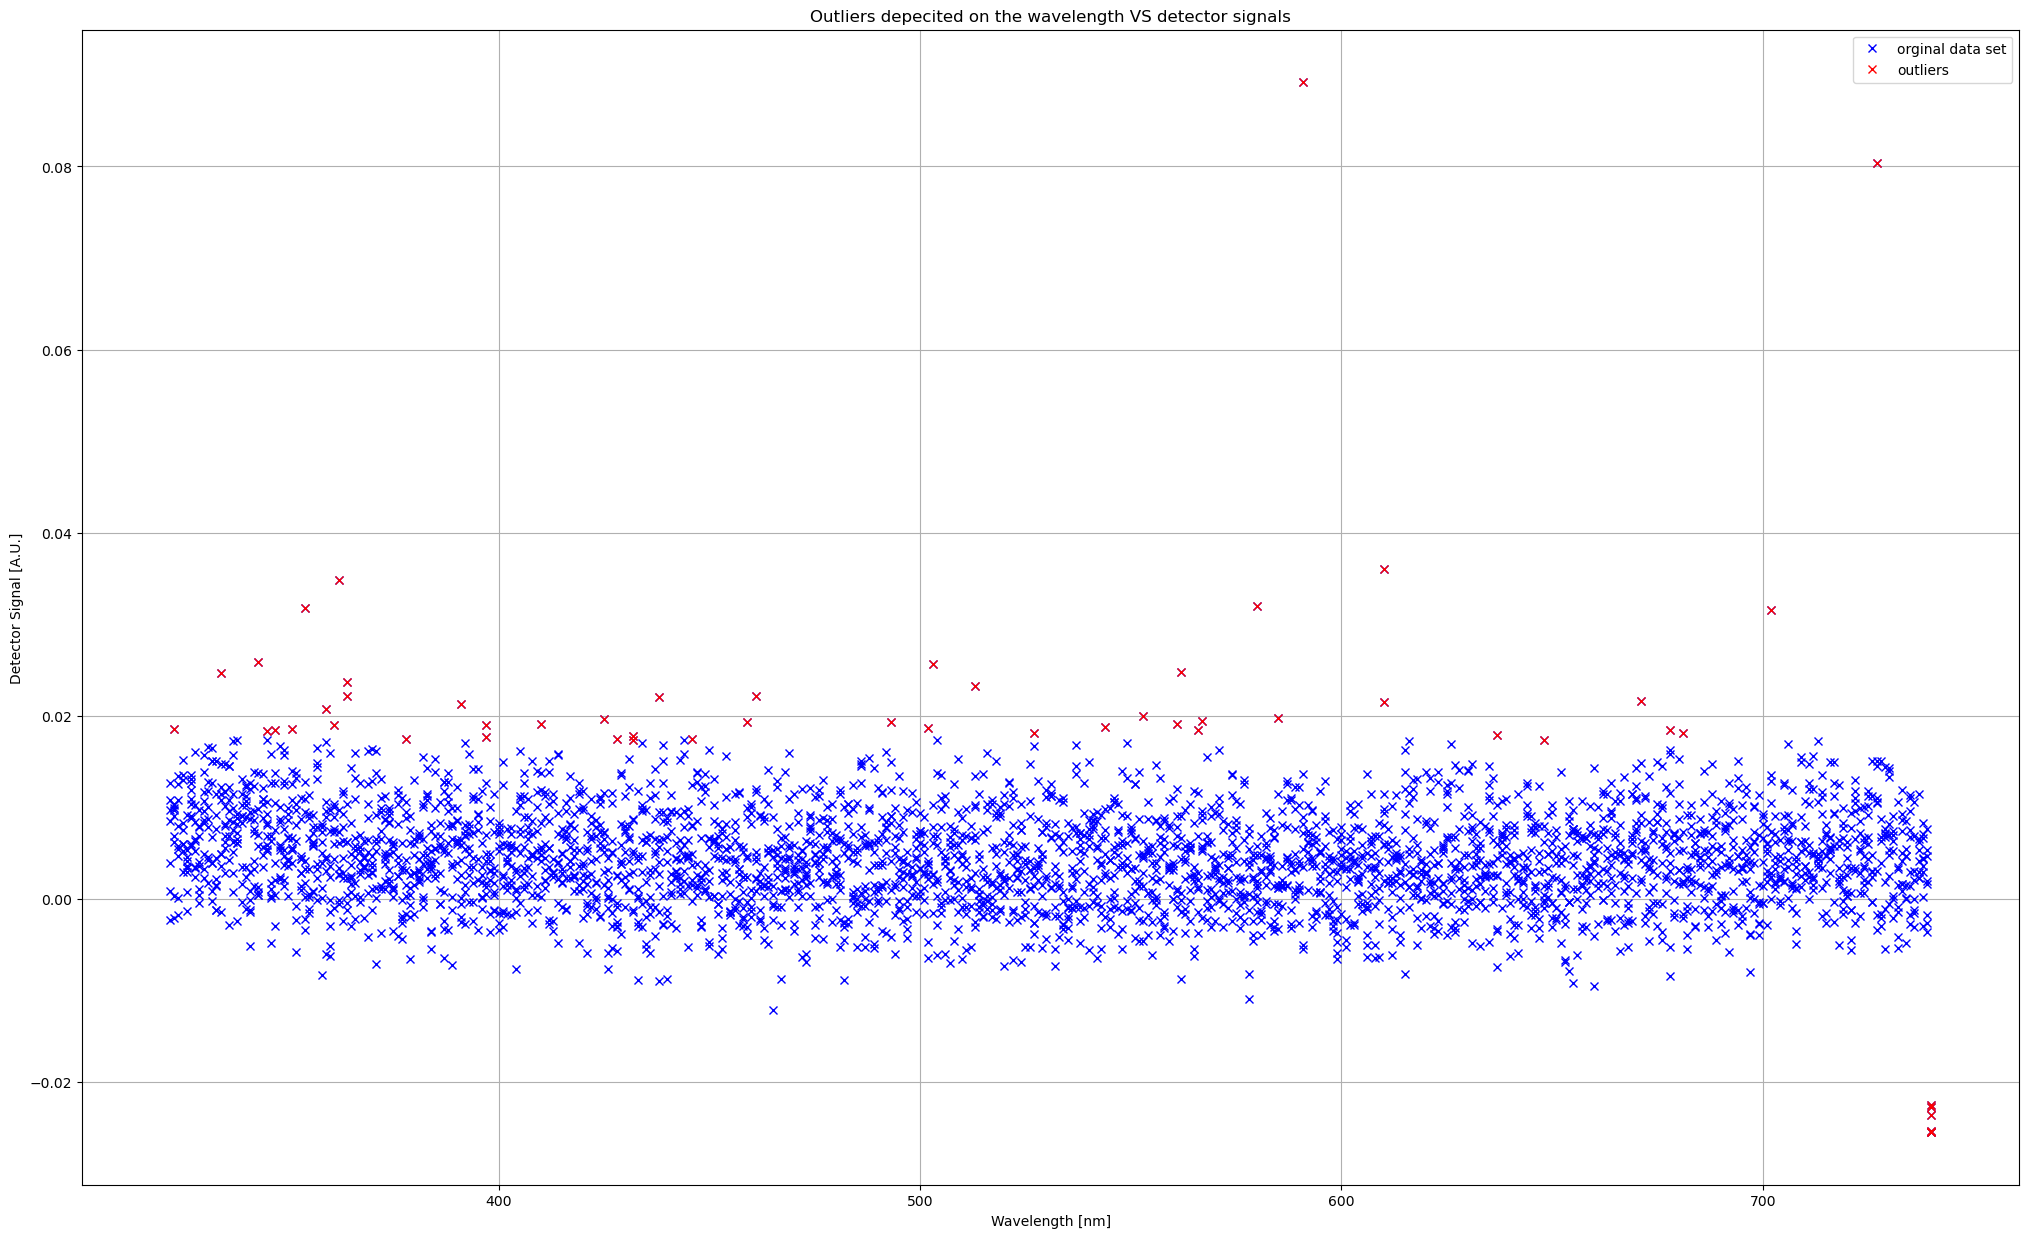

In [65]:
#plot the original and outliers and the same plot for confirmation that outliers were detected
plt.figure(figsize=(25,15))
plt.plot(wavelength, detector_signal, "x", color = 'blue', label = "orginal data set")
plt.plot(wavelength[outliers], detector_signal[outliers], "x", color = 'red', label = "outliers")
plt.grid()

plt.title('Outliers depecited on the wavelength VS detector signals')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Detector Signal [A.U.]')
plt.legend()

Now recalculate the average and sigma without these points

Let us now exclude (not a usual practice and not acceptable given the one-to-one association to wavelength) these points and look closely to the noise distribution.

In [69]:
##STUDENT GENERATED CELL  2: 

#Re-calculate the statistics of the dataset without the outliers

#exclude the outliers 
non_outlier_wavelength = np.delete (wavelength, outliers )
non_outlier_signals = np.delete (detector_signal, outliers )


#compute mean without outliers
new_mean = np.mean (non_outlier_signals)
print (f"The mean of the data set without outliers is: {new_mean:.5f}")

#compute std without outliers
new_std = np.std (non_outlier_signals)
print (f"The standard deviation of the data set without outliers is: {new_std:.5f}")



The mean of the data set without outliers is: 0.00430
The standard deviation of the data set without outliers is: 0.00499


Lets plot the outlier-excluded data to investigate the noise in the data:

Text(0, 0.5, 'Detector Signal [A.U.]')

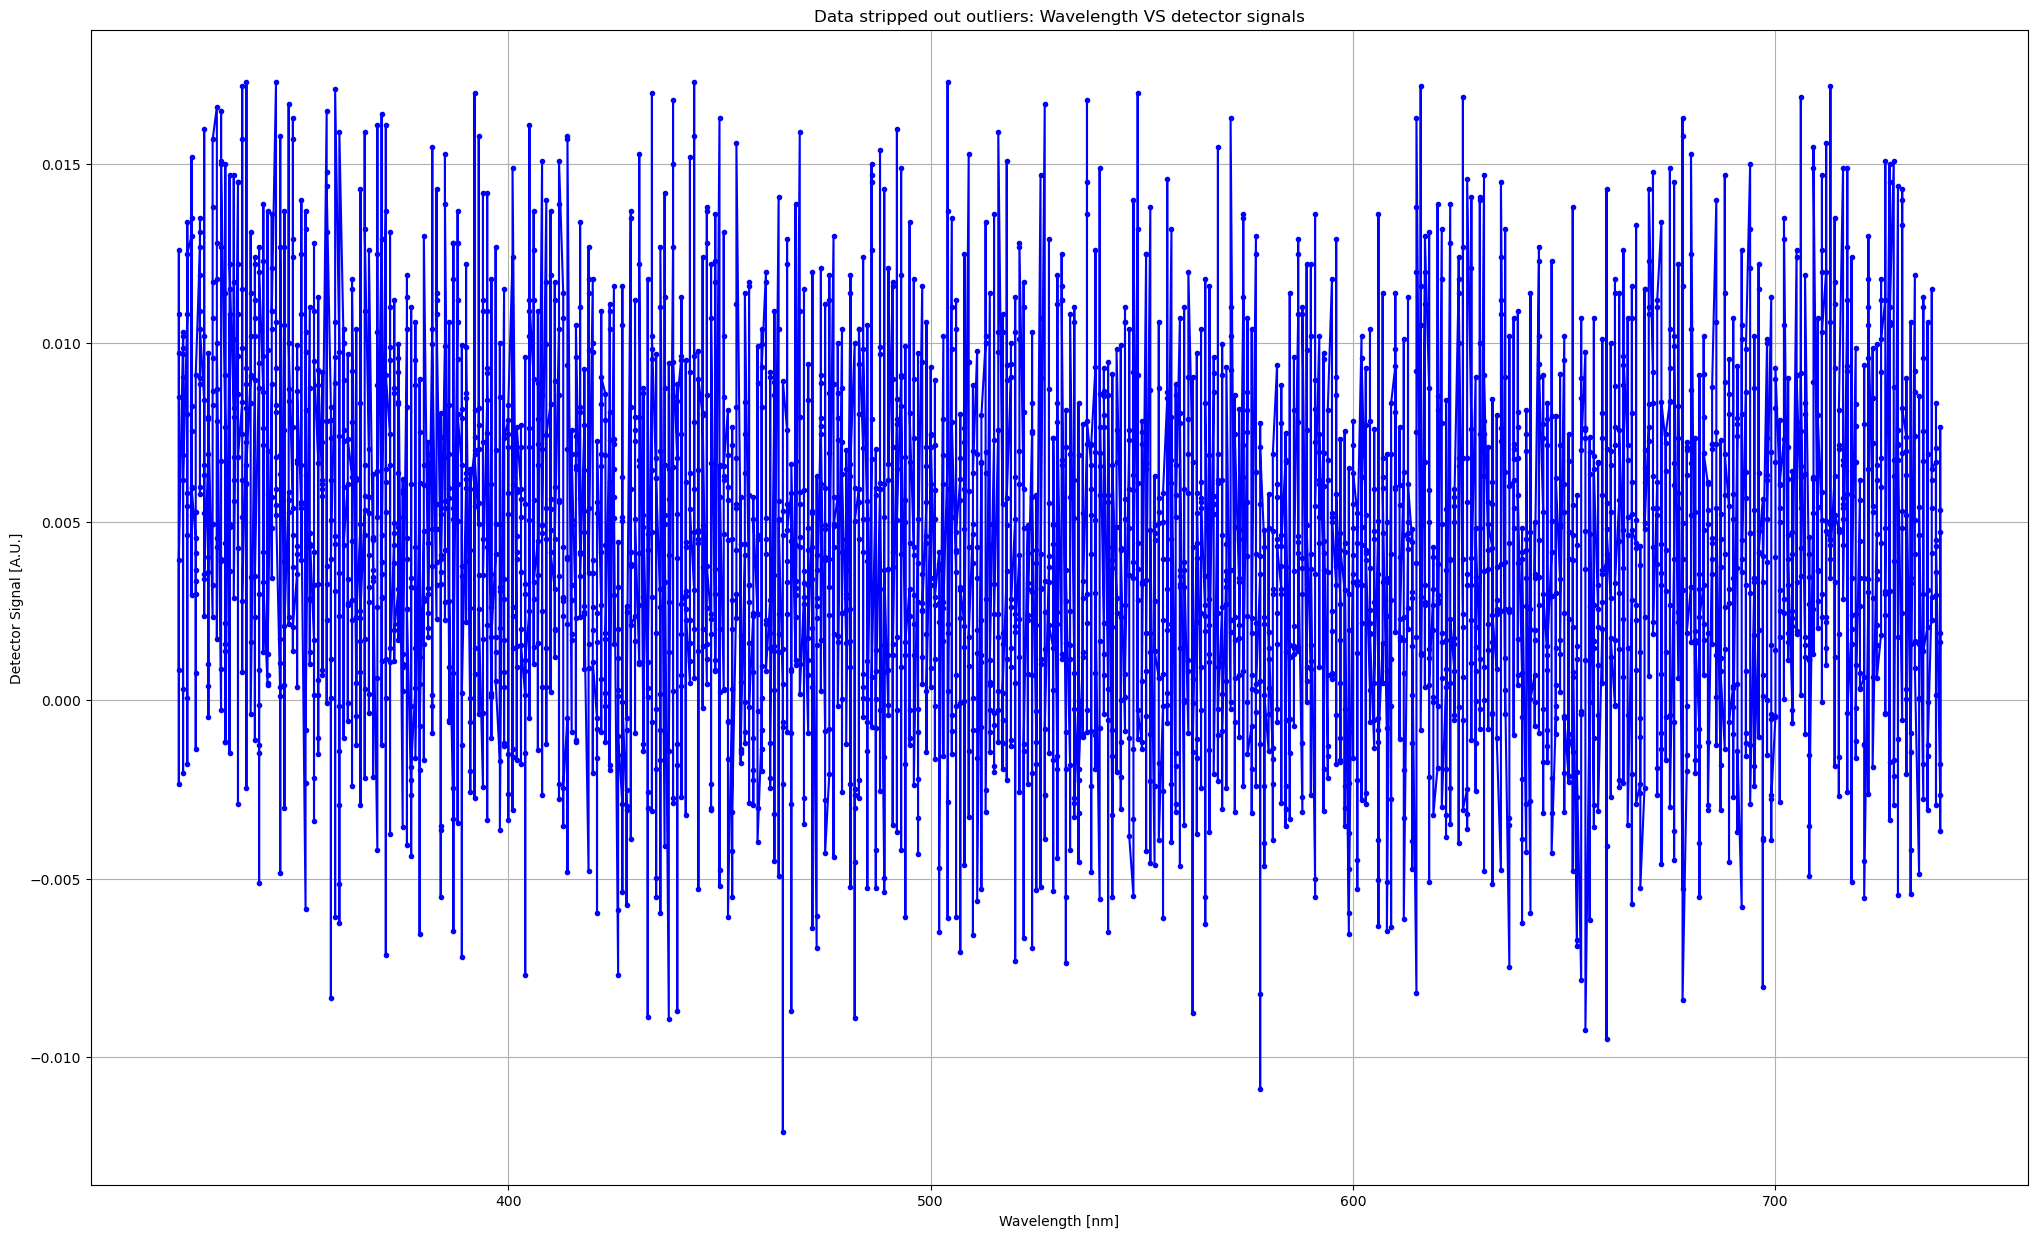

In [72]:
#STUDENT GENERATED CELL 

#plot non-outlier data
plt.figure(figsize=(25,15))
plt.plot(non_outlier_wavelength, non_outlier_signals, marker = ".", color = 'blue')
plt.grid()

plt.title('Data stripped out outliers: Wavelength VS detector signals')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Detector Signal [A.U.]')


We see that the data still contains noise after excluding outliers, nevertheless the new caluclated standard deviation shows that our data is less nuanced.

## TASK 3: Introducing the concept of Jack Knife ##

**Jack Knife on the 1D data** 
Take the 1D data set and re-perform statistical analysis on two separate halves of the data set.
Case 1: Half data set if the first half (0-1823) and the second half (1824-3647). This allows to check if there is a physical effect affecting the data locally because of any (discuss) effect that might be present.
Case 2: Consider two halves by selecting all odd pixels vs all even pixels. (seemingly not an effect that one would expect to yield a result - control-experiment)

Create as many code cells below to perform the above tasks.
Make sure that after each code cell (with appropriate comments) you also create Markdown cells in between to discuss and comment on the results that you obtain.

### Case 1: Splitting data into first and second half

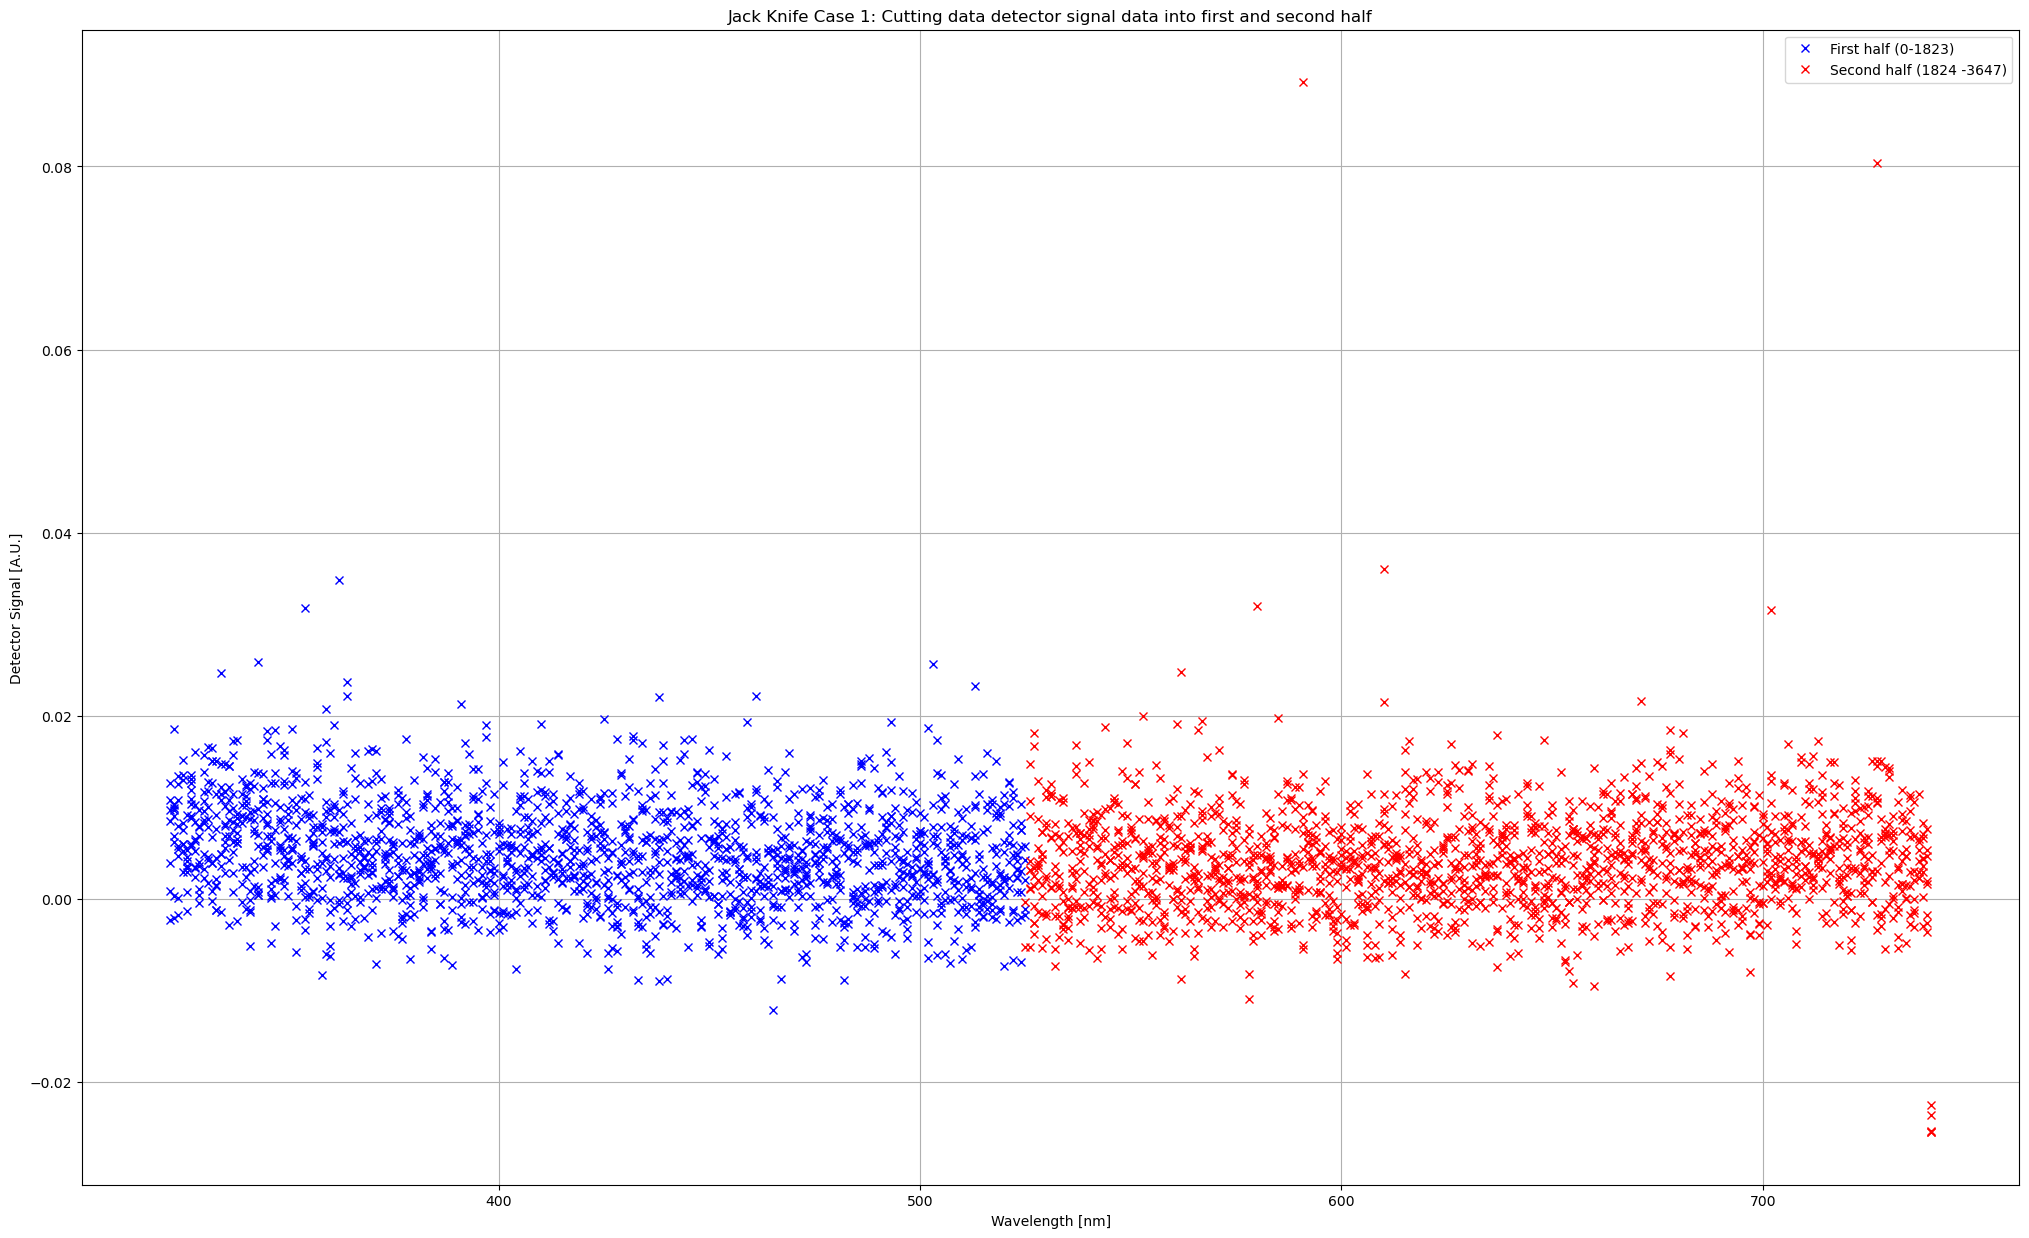

In [77]:
#STUDENT GENERATED CELL 

#CASE 1: cut the data set in half 
#wavelength
first_wavelength = wavelength [0:1823]
second_wavelength = wavelength [1824:3647]

#detector signal
first_detector = detector_signal [0:1823]
second_detector = detector_signal  [1824:3647]

#plotting the data 
plt.figure(figsize=(25,15))
plt.plot(first_wavelength, first_detector, "x", color = 'blue', label = "First half (0-1823)")
plt.plot(second_wavelength, second_detector, "x", color = 'red', label = "Second half (1824 -3647)")
plt.grid()

plt.title('Jack Knife Case 1: Cutting data detector signal data into first and second half')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Detector Signal [A.U.]')
plt.legend()


In [79]:
#CASE 1: stat analysis
mean_first = np.mean (first_detector)
print (f"Mean of the first half of the data set: {mean_first:.5f}")

std_first = np.std (first_detector)
print (f"Standard deviation of the first half of the data set: {std_first:.5f}")

mean_second = np.mean (second_detector)
print (f"Mean of the second half of the data set: {mean_second:.5f}")

std_second = np.std (second_detector)
print (f"Standard deviation of the second half of the data set: {std_second:.5f}")

Mean of the first half of the data set: 0.00499
Standard deviation of the first half of the data set: 0.00546
Mean of the second half of the data set: 0.00405
Standard deviation of the second half of the data set: 0.00600


### Case 2: Splitting according to even and odd pixels

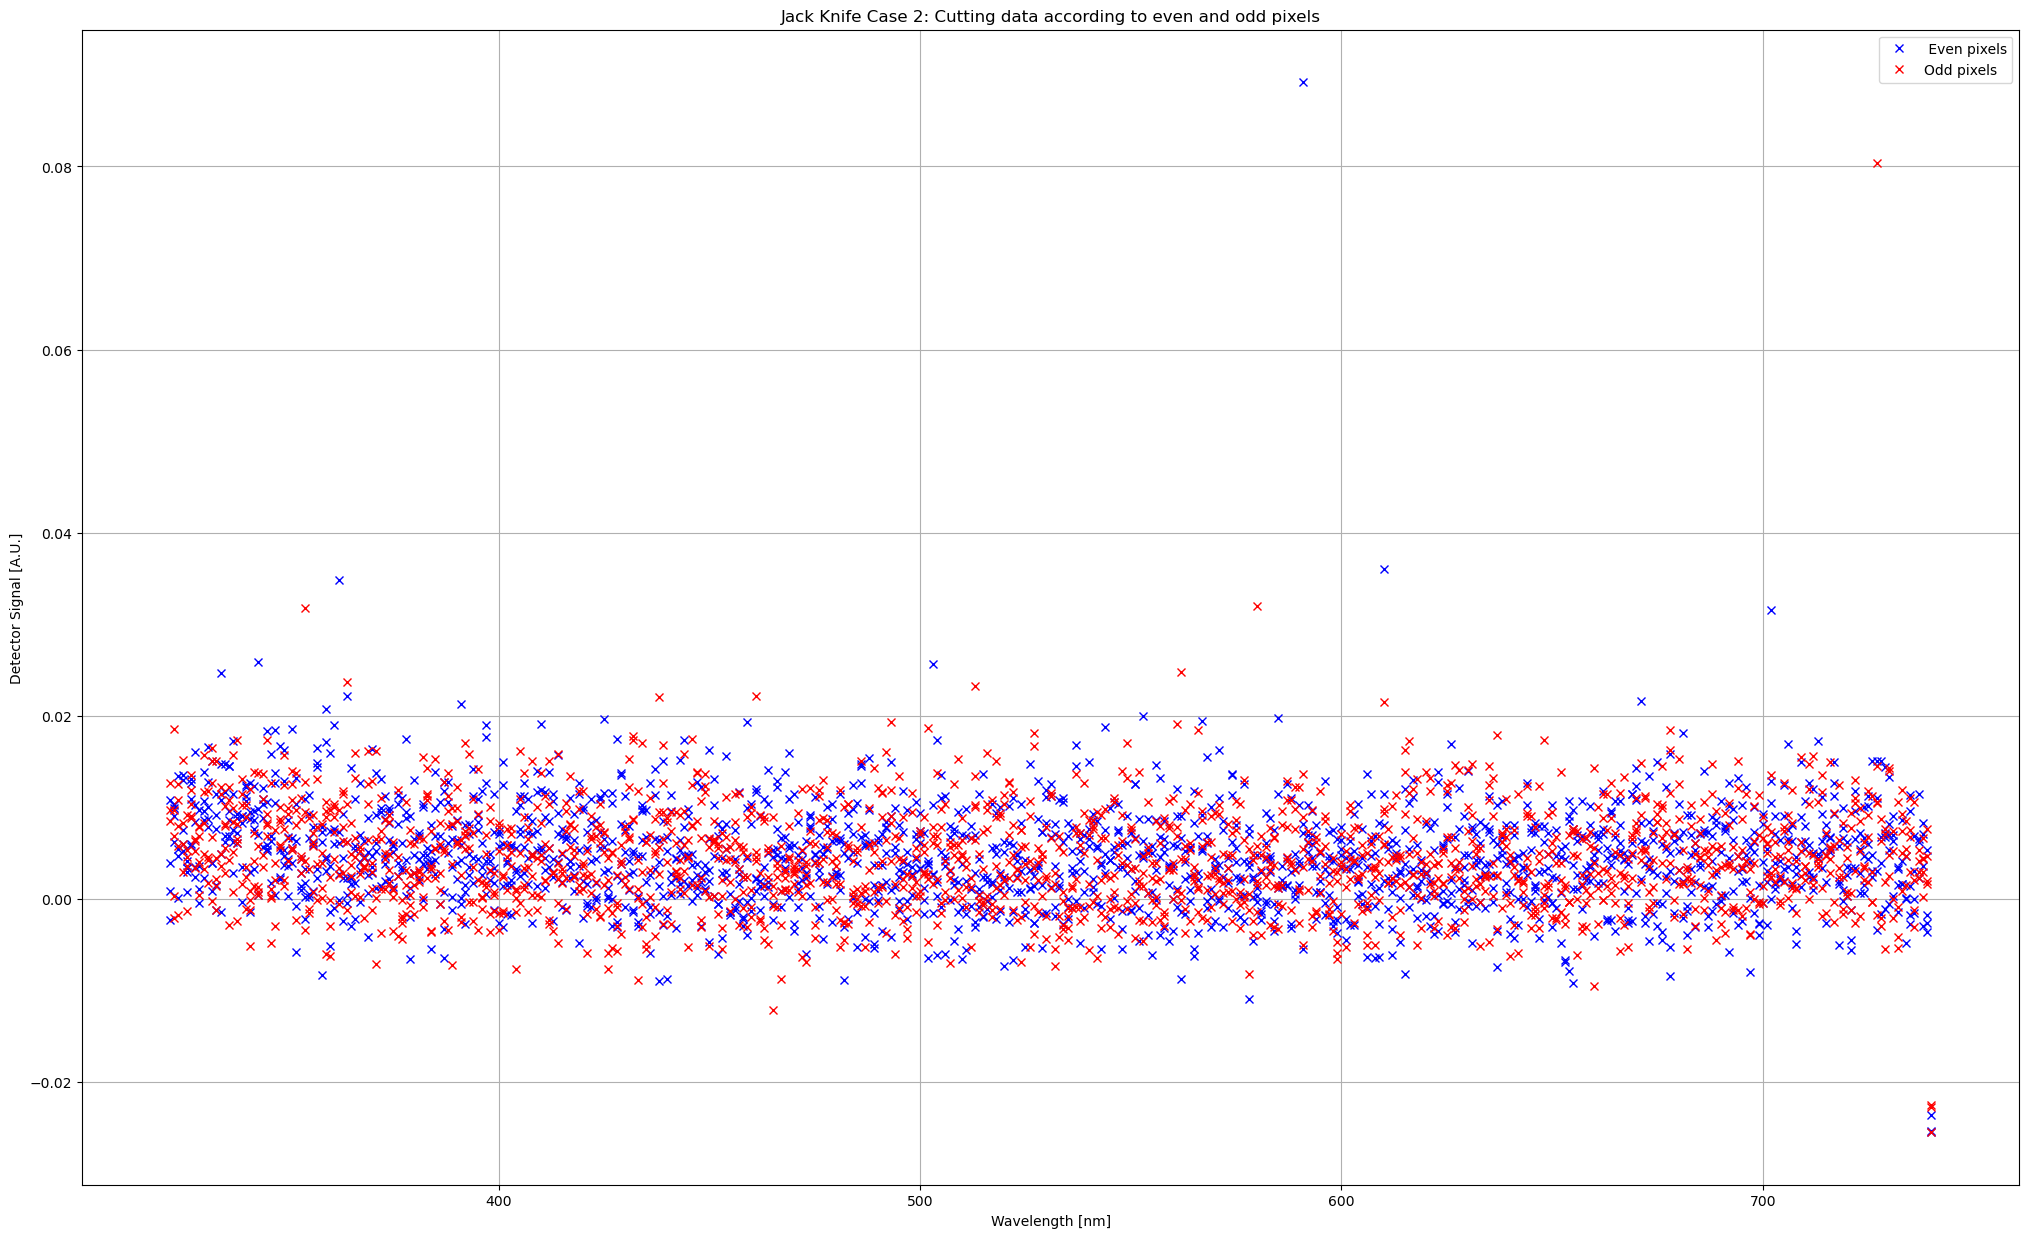

In [82]:
#STUDENT GENERATED CELL 

#CASE 2: even VS odd
#first we do detector_signal data to find odd and even pixels
even_signal = detector_signal [::2]
odd_signal = detector_signal [1::2]

#now for the wavelengths
even_wavelength = wavelength [::2]
odd_wavelength = wavelength [1::2]

#plotting the data 
#ON ONE GRAPH TWO DIFF COLOURS
plt.figure(figsize=(25,15))
plt.plot(even_wavelength, even_signal, "x", color = 'blue', label = " Even pixels")
plt.plot(odd_wavelength, odd_signal, "x", color = 'red', label = "Odd pixels")
plt.grid()

plt.title('Jack Knife Case 2: Cutting data according to even and odd pixels')
plt.xlabel('Wavelength [nm]')
plt.ylabel('Detector Signal [A.U.]')
plt.legend()


In [84]:
#CASE 2: stat analysis
mean_even = np.mean (even_signal)
print (f"The mean for the even pixels is: {mean_even:.5f}")

std_even = np.std (even_signal)
print (f"The standard deviation for even pixels is: {std_even:.5f}")

mean_odd = np.mean (odd_signal)
print (f"The mean for the odd pixels is: {mean_odd:.5f}")

std_odd = np.std (odd_signal)
print (f"The standard deviation for the odd pixels is: {std_odd:.5f}")

The mean for the even pixels is: 0.00464
The standard deviation for even pixels is: 0.00584
The mean for the odd pixels is: 0.00439
The standard deviation for the odd pixels is: 0.00570


In conclusion, we can infer that the Jack Knife of Case 2 is more suitable as it splits the data set into two data sets that are more equal. This can be seen visually on the graph, and from our calculated standard deviations. For Case 2, the standard deviations for the odd and even data sets are very similar. For Case 1, we see on the graph that the greatest outliers are loacted in the second part of the data, making its standard deviation larger than the one of the first part of the data. Hence this investigation concludes that Case 2 would be more suitable to use for the user. 

### TASK 4 ###

<div class="alert alert-warning">

<ul>
<li>Load the set of 10 files of similar dark data.
Compare the histogam of any of those sets with that of the average-per-pixel of the 10 datasets. 
For gaussian distributed values, we would expect that the standard deviation is reduced by a factor of $\sqrt 10$. What do you notice comparing the two distributiTheons?</li>

<li> Now load the two datasets from a different instrument (you'll have to check the format that might be different). These have a different integration time (1 and 10s). Use these two files to try and separate the average Bias from the DarkCurrent behaviour.</

<li> First do this assuming that all pixels are well behaved and the values of DC normally distributed, then similarly to the previous task remove the excess noise to recalculate a more realistic value for the dark current. </li>

<li> Comment on your results</li>
</ul>

</div>

### Part 1: Working with the 10 dark_test csv data sets 

In [89]:
# STUDENT GENERATED CELL

#set appropriate traces 
tpath = "./10_traces/"

#load the data, would be more reasonable through a loop
tdata_0 = np.loadtxt(tpath + 'Dark_test_000000000.csv',delimiter=';',skiprows=53,max_rows=3648) 
tdata_1 = np.loadtxt(tpath + 'Dark_test_000000001.csv',delimiter=';',skiprows=53,max_rows=3648)
tdata_2 = np.loadtxt(tpath + 'Dark_test_000000002.csv',delimiter=';',skiprows=53,max_rows=3648)
tdata_3 = np.loadtxt(tpath + 'Dark_test_000000003.csv',delimiter=';',skiprows=53,max_rows=3648)
tdata_4 = np.loadtxt(tpath + 'Dark_test_000000004.csv',delimiter=';',skiprows=53,max_rows=3648)
tdata_5 = np.loadtxt(tpath + 'Dark_test_000000005.csv',delimiter=';',skiprows=53,max_rows=3648)
tdata_6 = np.loadtxt(tpath + 'Dark_test_000000006.csv',delimiter=';',skiprows=53,max_rows=3648)
tdata_7 = np.loadtxt(tpath + 'Dark_test_000000007.csv',delimiter=';',skiprows=53,max_rows=3648)
tdata_8 = np.loadtxt(tpath + 'Dark_test_000000008.csv',delimiter=';',skiprows=53,max_rows=3648)
tdata_9 = np.loadtxt(tpath + 'Dark_test_000000009.csv',delimiter=';',skiprows=53,max_rows=3648)


#isolating two columns 

#we will only need one array for wavelength as that is the same across the images
wavelength_dark_test = tdata_0[:,0]

#now we store the detector signals for all the data sets
detector_signal_0 = tdata_0 [:,1]
detector_signal_1 = tdata_1 [:,1]
detector_signal_2 = tdata_2 [:,1]
detector_signal_3 = tdata_3 [:,1]
detector_signal_4 = tdata_4[:,1]
detector_signal_5 = tdata_5 [:,1]
detector_signal_6 = tdata_6 [:,1]
detector_signal_7 = tdata_7 [:,1]
detector_signal_8 = tdata_8 [:,1]
detector_signal_9 = tdata_9 [:,1]


We now add all the detector signals for all the 10 data sets and find the average per pixel. We will then plot a histogram from this and compare it to just one data set.

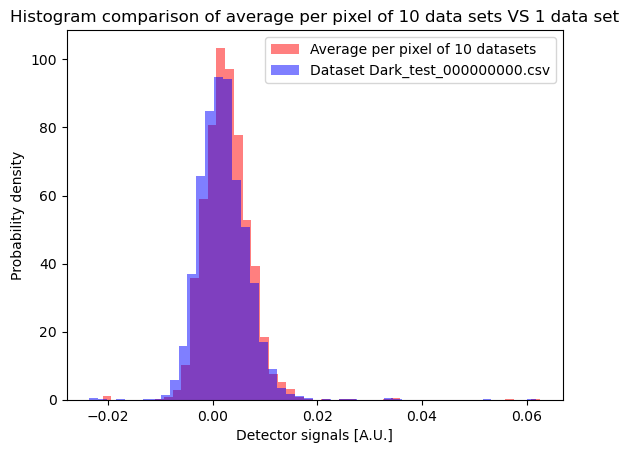

In [92]:
# STUDENT GENERATED CELL

#add the detector arrays together to one big array
detector_signal_all = detector_signal_0 + detector_signal_1  + detector_signal_2 + detector_signal_3 + detector_signal_4 + detector_signal_5 + detector_signal_6 + detector_signal_7 + detector_signal_8 + detector_signal_9
mean_detector = detector_signal_all/10

#plotting the histogram
plt.hist (mean_detector, color = 'red', bins = 50, density = True, alpha = 0.5, label = 'Average per pixel of 10 datasets') #alpha sets opacity of distribution
plt.hist (detector_signal_0, color = 'blue', bins = 50, density = True, alpha = 0.5, label = 'Dataset Dark_test_000000000.csv')

#add adding plot elements
plt.title ("Histogram comparison of average per pixel of 10 data sets VS 1 data set")
plt.xlabel('Detector signals [A.U.]')
plt.ylabel('Probability density')
plt.legend ()


In [94]:
#compute the std of the 10 datasets and the single data set
detector_all_std = np.std(mean_detector)
print (f"The computed standard deviation of the 10 data sets is: {detector_all_std:.5f}")

detector_0_std = np.std(detector_signal_0)
print (f"The standard deviation of the single data set is: {detector_0_std:.5f}")

The computed standard deviation of the 10 data sets is: 0.00447
The standard deviation of the single data set is: 0.00465


In [96]:
# compare to root 10
root10 = detector_0_std/ np.sqrt(10)
print(f"The expected standard deviation for the 10 data sets is: {root10:.5f}")

The expected standard deviation for the 10 data sets is: 0.00147


The histograms show us that these two data sets coincide with one another however the standard deviation of the data set with the 10 files are about three times larger than we expected ($sqrt{10}$ expected). The theoretical expectation does not match the actual result as we are not working with perfect data and hence uncertainities still persist even when we try to eliminate random errors by combining data sets. This can indicate a presence of systematic errors and higher noise levels than initially expected.

### Part 2: working with spectral_1s and spectral_10s

In [100]:
# STUDENT GENERATED CELL

#loading data sets from two different intruments
tpath =  "./PythonTask_1/ "
tdata_1 = np.loadtxt('Spectral_1sExp.csv',delimiter=',',skiprows=21,max_rows=2520) #1s integration time
tdata_10 = np.loadtxt('Spectral_10sExp.csv',delimiter=',',skiprows=21,max_rows=2520) #10s integration time

#separate data for Spectral_1sExp frame
wavelength_spectral_1 = tdata_1[:,0]
detector_signal_1 = tdata_1 [:,1]

#separate data for Spectral_10sExp frame
wavelength_spectral_10 = tdata_10[:,0]
detector_signal_10 = tdata_10[:,1]


We will use these two files to try and separate the average Bias from the Dark Current. We will use the formula stated at the start of this notebook:
$$ D = B + DC \cdot t + S(t) $$
- S is zero for dark frames and spectral images
- D is the detector signal
- t is the exposure time
- DC is the dark current

Let us now use this to find DC and bias. 



In [103]:
# STUDENT GENERATED CELL

#separating the Bias and the Dark current in the spectral frames
#for Spectral_1sExp, t = 1s
#for dark1000ms, t = 1s
#assume that spectral images have s(t) = 0

#calculate the dark current per one second
dark_current = detector_signal_10 - detector_signal_1/ (10-1)



Text(0, 0.5, 'Probability density')

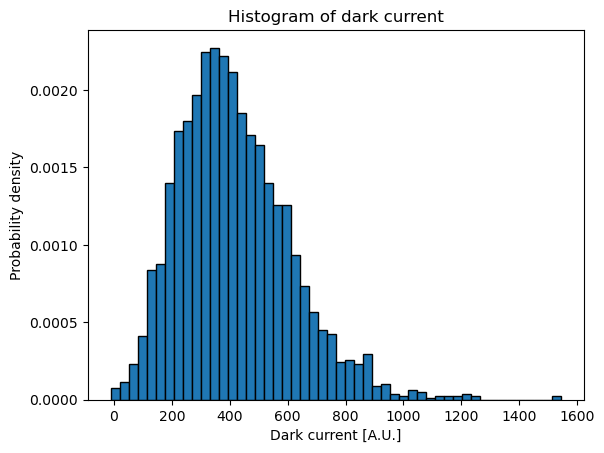

In [105]:
#plot the values of DC to check if they are normally distributed

#plot
plt.hist (dark_current, edgecolor='black', bins = 50, density = True)

#add adding plot elements
plt.title ("Histogram of dark current")
plt.xlabel('Dark current [A.U.]')
plt.ylabel('Probability density')



The histogram of Dark Current follows a Poissonian statistics which is expected for data sets of dark currents. In the next part we will try to strip the outliers and see if this shifts the distribution towards a Gaussian.

In [108]:
#find av. value of dark current 
mean_dark = np.mean(dark_current)
print (f"The mean dark current per pixel is {mean_dark:.2f}")

#find std 
#find av. value of dark current 
std_dark = np.std(dark_current)
print (f"The std dark current per pixel is {std_dark:.2f}")

The mean dark current per pixel is 416.31
The std dark current per pixel is 195.18


Let's now find the bias for the spectral frame with exp 1s and 10s:

In [111]:
#now calculate bias for each image 
bias_1 = detector_signal_1 - dark_current
bias_10 = detector_signal_10 - (dark_current*10)


### Part 3: Removing outliers and obtaining new dark current values

In [114]:
#TRY REMOVING outliers directly from dark current
outlier_threshold_dark = 4*np.std(dark_current)

#identify pixels that have standard deviation greater than outlier threshold using np.where 
outliers_dark = np.where (np.abs(dark_current) > outlier_threshold_dark)


In [116]:
#new arrays
non_outlier_wavelength_dark = np.delete (wavelength_spectral_1, outliers_dark )
non_outlier_dark = np.delete (dark_current, outliers_dark )

print(len(non_outlier_wavelength_dark))
print(len(non_outlier_dark))

2386
2386


Text(0, 0.5, 'Probability density')

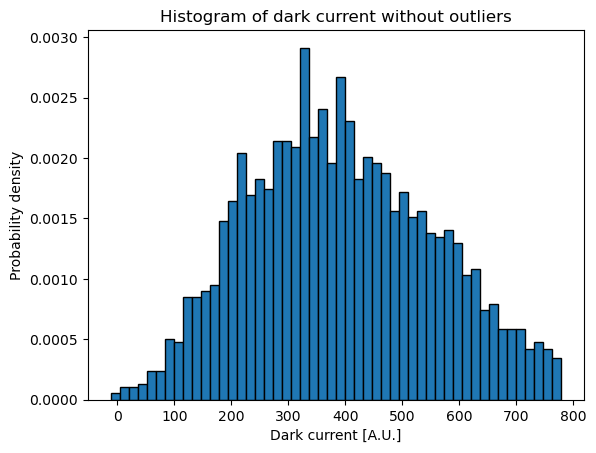

In [118]:
#the plot of data without outliers
plt.hist (non_outlier_dark, edgecolor='black', bins = 50, density = True)

#add adding plot elements
plt.title ("Histogram of dark current without outliers")
plt.xlabel('Dark current [A.U.]')
plt.ylabel('Probability density')

We see that by removing the outliers, the distribution becomes normally distributed. Let's calculate the stats of this new data set.

In [121]:
#find av. value of dark current 
new_mean_dark = np.mean(non_outlier_dark)
print (f"The mean dark current per pixel is {new_mean_dark:.2f}")

#find std 
#find av. value of dark current 
new_std_dark = np.std(non_outlier_dark)
print (f"The std dark current per pixel is {new_std_dark:.2f}")

The mean dark current per pixel is 392.20
The std dark current per pixel is 161.81


**STUDENT GENERATED CELL**

Comparing the stats, we see that the standard deviation of the distribution decreases indicating that a data set with no outliers in more suitable to this fit. The mean value also decreases. This makes sense as outlier pixels carry higher dark currents due to higher fluctuations of temperature in the sensor. 

### TASK 5 ###

<div class="alert alert-warning">

Load the file "Dark_with_Temp_set.csv" which has a different format (so review the call line to adjust header lines and rows - you can check the file by opening them with a generic text editor).

Aside for the first column which are the wavelengths of each pixel, each column is the dark data set for a different temperature measured on the chassis of the spectrometer (which can be assumed to be close to that of the detector).

Use the information on the bias value obtained and show in a way you see appropriate how the mean Dark Current of the detector changes with Temperature.
You can use the Arrhenius Law to model this behaviour.

</div>

In [125]:
# STUDENT GENERATED CELL
#This file will have 8 columns (for 7 temperature data points)
tpath = "./PythonTask_1/ "
tdata_set = np.loadtxt('Dark_with_Temp_set.csv',delimiter=',',skiprows=21,max_rows=2520)

#separate data (perphas put it in a loop)
wavelength_temp = tdata_set[:,0]
signals_temp_1 = tdata_set[:,1]
signals_temp_2 = tdata_set[:,2]
signals_temp_3 = tdata_set[:,3]
signals_temp_4 = tdata_set[:,4]
signals_temp_5 = tdata_set[:,5]
signals_temp_6 = tdata_set[:,6]
signals_temp_7 = tdata_set[:,7]



To find the dark current for each of these data sets we employ the same formula as before. As the exposure time is one second, the formula reduces to:
$$
DC = D - B
$$

We will find the mean value of the dark current for each data set as we will later make a plot against respective temperatures.

In [128]:
# using the bias we obtained from Spectral_1sExp we find the darks 
dc_1 = np.mean (signals_temp_1 - bias_1)
dc_2 = np.mean (signals_temp_2 - bias_1)
dc_3 = np.mean (signals_temp_3 - bias_1)
dc_4 = np.mean (signals_temp_4 - bias_1)
dc_5 = np.mean (signals_temp_5 - bias_1)
dc_6 = np.mean (signals_temp_6 - bias_1)
dc_7 = np.mean (signals_temp_7 - bias_1)

#load the averages in an array
dc = np.array ([dc_1, dc_2, dc_3, dc_4, dc_5, dc_6, dc_7])
    

Now, let us load the temperatures for each data set into an array. We will then create a plot following the Arrhenius Law. This will place $\frac{1}{Temperature}$ on the x-axis and $ln(DC)$ on the way axis, hoping to linearize our plot.

Text(0, 0.5, 'ln (DC) [A.U.]')

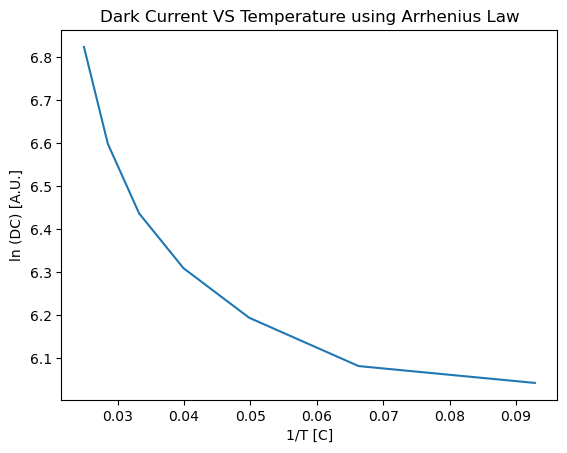

In [131]:
#extracting temperatures 
temp_data = np.array ([10.77267, 15.08389, 20.08005, 25.05142, 30.08786, 35.05212, 40.11432])

#Arrhenius law: 1/T on x-axis), ln(DC) on y-axis
x_values = 1/temp_data
y_values = np.log(dc)

#plot
plt.plot(x_values, y_values)

#add adding plot elements
plt.title ("Dark Current VS Temperature using Arrhenius Law")
plt.xlabel('1/T [C]')
plt.ylabel('ln (DC) [A.U.]')



In conclusion, we see that modelling our data according to the Arrhenius Law does not strictly linearise them. Arrhenius law can be useful in modelling the thermal processes in the detector. Indeed, it allows us to understand that the Dark Current increases with the temprature of the detector. A further investigation could be made to understand why this data does not appear linear in this plot with a possible expansion in elimitaing outliers of each data set or attempt to fit it to other models. 